**_Copyright Notice_**

This notebook is available for educational purposes. You may not use or distribute this notebook for commercial purposes. You may make copies of this notebook and use or distribute it for educational purposes as long as you cite the author as the source of the notebook.

Jaeyoung Chun | School of Applied Artificial Intelligence | Handong Global University

# FIFA World Cup 2022 Simulation and Prediction

In [1]:
import pickle
import pandas as pd
import numpy as np

from IPython.display import display

from scipy.stats import poisson

## Load Predictor

In [2]:
with open("./intermediate/predictor.pickle", "rb") as fin:
    predictor = pickle.load(fin)

In [3]:
predictor

{'team_feats': {'Qatar': {'goals_avg': np.float64(1.6440677966101696),
   'goals_suf_avg': np.float64(0.6232344632768363),
   'rank_avg': np.float64(72.67796610169492),
   'points_avg': np.float64(1372.2545762711866),
   'goals_avg_lastn': np.float64(0.6),
   'goals_suf_avg_lastn': np.float64(1.0),
   'rank_avg_lastn': np.float64(51.0),
   'points_avg_lastn': np.float64(1435.962)},
  'Ecuador': {'goals_avg': np.float64(1.3404255319148937),
   'goals_suf_avg': np.float64(-0.9304078014184398),
   'rank_avg': np.float64(36.148936170212764),
   'points_avg': np.float64(1401.2436170212766),
   'goals_avg_lastn': np.float64(0.6),
   'goals_suf_avg_lastn': np.float64(0.8),
   'rank_avg_lastn': np.float64(29.2),
   'points_avg_lastn': np.float64(1457.252)},
  'Senegal': {'goals_avg': np.float64(1.5555555555555556),
   'goals_suf_avg': np.float64(0.27555555555555555),
   'rank_avg': np.float64(96.31111111111112),
   'points_avg': np.float64(1541.389111111111),
   'goals_avg_lastn': np.float64(1

In [4]:
# features
team_feats = predictor["team_feats"]

# FIFA world cup ranking
worldcup_ranks = predictor["worldcup_ranks"]

# machine learning models
model_home = predictor["model"]["home"]
model_away = predictor["model"]["away"]

# column names of the features
col_features = predictor["model"]["col_features"]

In [5]:
def get_features(home_team, away_team, team_feats, worldcup_ranks):
    
    # features for home team
    feat_home = team_feats[home_team]

    # features for away team
    feat_away = team_feats[away_team]

    # for given two teams (home vs. away)
    # create a dictionary of features which will be fed into ML model
    row = {
        'rank_diff': worldcup_ranks[home_team] - worldcup_ranks[away_team],
        'goals_avg_diff': feat_home['goals_avg'] - feat_away['goals_avg'],
        'goals_avg_lastn_diff': feat_home['goals_avg_lastn'] - feat_away['goals_avg_lastn'],
        'goals_suf_avg_diff': feat_home['goals_suf_avg'] - feat_away['goals_suf_avg'],
        'goals_suf_avg_lastn_diff': feat_home['goals_suf_avg_lastn'] - feat_away['goals_suf_avg_lastn'],
        'rank_avg_diff': feat_home['rank_avg'] - feat_away['rank_avg'],
        'rank_avg_lastn_diff': feat_home['rank_avg_lastn'] - feat_away['rank_avg_lastn'],
        'points_avg_diff': feat_home['points_avg'] - feat_away['points_avg'],
        'points_avg_lastn_diff': feat_home['points_avg_lastn'] - feat_away['points_avg_lastn'],
    }
    
    return pd.DataFrame([row])[col_features]

In [6]:
def predict_match_result(team_home, team_away, team_feats, worldcup_rank):

    # we will compute probabilities for 0, 1, ..., 10 goals per team    
    max_goals = 10

    # get features
    X_match = get_features(team_home, team_away, team_feats, worldcup_rank)

    # predict goals for home team
    goals_home = model_home.predict(X_match).clip(min=0.0)
    lambda_home = goals_home.item()

    # predict goals for away team
    goals_away = model_away.predict(X_match).clip(min=0.0)
    lambda_away = goals_away.item()

    # get probabilities
    probs_home = np.array([poisson.pmf(g, lambda_home) for g in range(max_goals + 1)])
    probs_away = np.array([poisson.pmf(g, lambda_away) for g in range(max_goals + 1)])

    # create a score matrix using the probabilities
    score_matrix = np.round(np.outer(probs_home, probs_away), 2)
    score_matrix_perc = score_matrix * 100

    # probability for win, draw, lose
    prob_home_win = np.sum(np.tril(score_matrix_perc, -1))   # home > away (below diagonal)
    prob_draw     = np.sum(np.diag(score_matrix_perc))       # home == away (diagonal)
    prob_away_win = np.sum(np.triu(score_matrix_perc, 1))    # away > home (above diagonal)

    # most likely exact score
    idx = np.unravel_index(score_matrix_perc.argmax(), score_matrix_perc.shape)

    most_likely_score = (int(idx[0]), int(idx[1]))

    final_result = {
        'lambda_home': lambda_home,
        'lambda_away': lambda_away,
        'score_matrix': score_matrix_perc,
        'prob_home_win': prob_home_win,
        'prob_draw': prob_draw,
        'prob_away_win': prob_away_win,
        'most_likely_score': most_likely_score
    }

    return final_result

## Group Stage

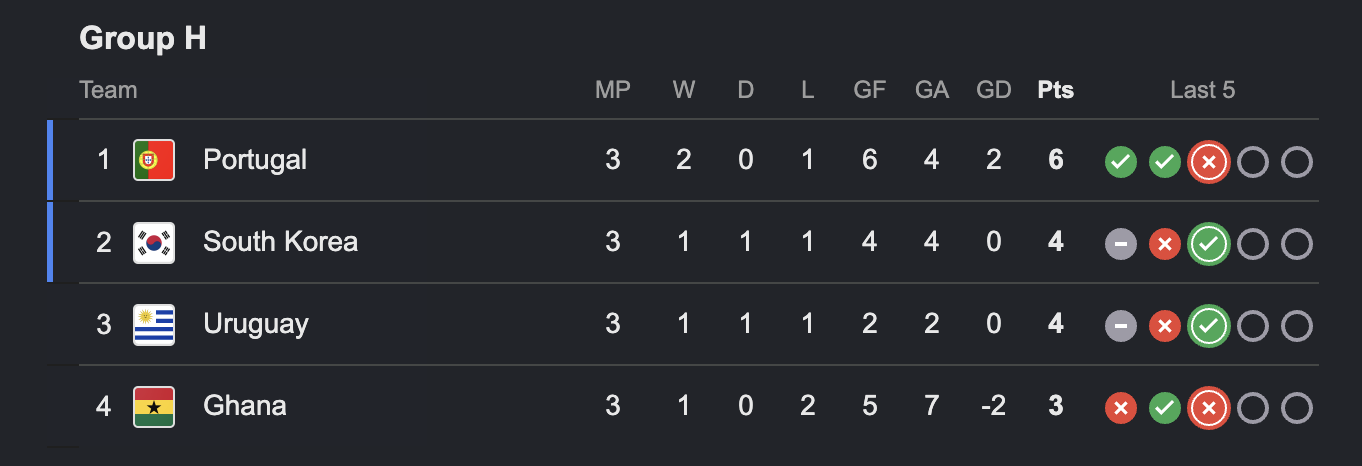

In [7]:
# FIFA World Cup 2022 Group Stage Fixtures
group_fixtures = {
    'A': [
        ('Qatar','Ecuador'),
        ('Senegal','Netherlands'),
        ('Qatar','Senegal'),
        ('Netherlands','Ecuador'),
        ('Netherlands','Qatar'),
        ('Ecuador','Senegal')
    ],
    'B': [
        ('England','Iran'),
        ('United States','Wales'),
        ('Wales','Iran'),
        ('England','United States'),
        ('Wales','England'),
        ('Iran','United States')
    ],
    'C': [
        ('Argentina','Saudi Arabia'),
        ('Mexico','Poland'),
        ('Poland','Saudi Arabia'),
        ('Argentina','Mexico'),
        ('Poland','Argentina'),
        ('Saudi Arabia','Mexico')
    ],
    'D': [
        ('Denmark','Tunisia'),
        ('France','Australia'),
        ('Tunisia','Australia'),
        ('France','Denmark'),
        ('Tunisia','France'),
        ('Australia','Denmark')
    ],
    'E': [
        ('Germany','Japan'),
        ('Spain','Costa Rica'),
        ('Japan','Costa Rica'),
        ('Spain','Germany'),
        ('Japan','Spain'),
        ('Costa Rica','Germany')
    ],
    'F': [
        ('Morocco','Croatia'),
        ('Belgium','Canada'),
        ('Belgium','Morocco'),
        ('Croatia','Canada'),
        ('Croatia','Belgium'),
        ('Canada','Morocco')
    ],
    'G': [
        ('Brazil','Serbia'),
        ('Cameroon','Switzerland'),
        ('Brazil','Switzerland'),
        ('Cameroon','Serbia'),
        ('Brazil','Cameroon'),
        ('Serbia','Switzerland')
    ],
    'H': [
        ('Uruguay','South Korea'),
        ('Portugal','Ghana'),
        ('South Korea','Ghana'),
        ('Portugal','Uruguay'),
        ('South Korea','Portugal'),
        ('Ghana','Uruguay')
    ],
}

In [8]:
# sanity check
# each group must have 6 matches
for group, fixtures in group_fixtures.items():
    print(f"Group {group} - Num of Matches: {len(fixtures)}")

Group A - Num of Matches: 6
Group B - Num of Matches: 6
Group C - Num of Matches: 6
Group D - Num of Matches: 6
Group E - Num of Matches: 6
Group F - Num of Matches: 6
Group G - Num of Matches: 6
Group H - Num of Matches: 6


In [9]:
group_results = {}

for group, fixtures in group_fixtures.items():

    # `group`
    # A, B, C, ..., H
    
    # `fixtures`
    # [('Qatar', 'Ecuador'), ('Senegal', 'Netherlands'), ('Qatar', 'Senegal'), ('Netherlands', 'Ecuador'), ('Netherlands', 'Qatar'), ('Ecuador', 'Senegal')]

    # {'Qatar': 0, 'Ecuador': 0, 'Senegal': 0, 'Netherlands': 0}
    team_dict = {team: 0 for pair in fixtures for team in pair}
    
    points = team_dict.copy() # Pts
    goals_for = team_dict.copy() # GF
    goals_against = team_dict.copy() # GA
    goals_diff  = team_dict.copy()  # GD

    wins = team_dict.copy() # W
    draws = team_dict.copy() # D
    losses = team_dict.copy() # L

    records = []
    
    for team_home, team_away in fixtures:

        # predict
        out = predict_match_result(team_home, team_away, team_feats, worldcup_ranks)

        # most likely score
        goals_home, goals_away = out['most_likely_score']

        # GF
        goals_for[team_home] += goals_home
        goals_for[team_away] += goals_away

        # GA
        goals_against[team_home] += goals_away
        goals_against[team_away] += goals_home
        
        # GD
        goals_diff[team_home] += goals_home - goals_away
        goals_diff[team_away] += goals_away - goals_home

        # Pts, W, D, L
        if goals_home > goals_away:
            points[team_home] += 3            
            wins[team_home] += 1
            losses[team_away] += 1
            outcome = f"{team_home} win"
        elif goals_home == goals_away:
            points[team_home] += 1
            points[team_away] += 1            
            draws[team_home] += 1
            draws[team_away] += 1
            outcome = "Draw"
        else:
            points[team_away] += 3            
            wins[team_away] += 1
            losses[team_home] += 1
            outcome = f"{team_away} win"

        records.append({
            "Team A": team_home,
            "Team B": team_away,
            'Predicted Score': f"{goals_home}–{goals_away}",
            'Team A λ': f"{out["lambda_home"]:.2f}",
            'Team B λ': f"{out["lambda_away"]:.2f}",
            'Team A Win %': f"{out['prob_home_win']:.0f}%",
            'Draw %': f"{out['prob_draw']:.0f}%",
            'Team B Win %': f"{out['prob_away_win']:.0f}%",
            'Outcome': outcome
        })

    df_fixtures = pd.DataFrame(records)
        
    # build standings
    standings = pd.DataFrame({
        "Team": list(points.keys()),
        "W": list(wins.values()),
        "D": list(draws.values()),
        "L": list(losses.values()),
        "GF": list(goals_for.values()),
        "GA": list(goals_against.values()),
        "GD": [goals_diff[team] for team in team_dict.keys()],
        "Pts": list(points.values())
    })
    standings.sort_values(["Pts", "GD"], ascending=False, inplace=True) # sort by points and goal differences
    standings.reset_index(inplace=True, drop=True) # add ranking
    standings.index += 1 # 0,1,2,3 --> 1,2,3,4

    group_results[group] = {
        "standings": standings,
        "fixtures": df_fixtures
    }

In [10]:
group_results["H"]["fixtures"]

,Team A,Team B,Predicted Score,Team A λ,Team B λ,Team A Win %,Draw %,Team B Win %,Outcome
0,Uruguay,South Korea,1–0,1.75,0.73,59%,22%,15%,Uruguay win
1,Portugal,Ghana,2–0,2.47,0.41,83%,13%,3%,Portugal win
2,South Korea,Ghana,1–0,1.51,0.65,57%,26%,17%,South Korea win
3,Portugal,Uruguay,1–0,1.39,0.88,48%,28%,23%,Portugal win
4,South Korea,Portugal,0–1,0.83,1.66,18%,24%,55%,Portugal win
5,Ghana,Uruguay,0–1,0.86,1.23,26%,28%,42%,Uruguay win


In [11]:
group_results["H"]["standings"]

,Team,W,D,L,GF,GA,GD,Pts
1,Portugal,3,0,0,4,0,4,9
2,Uruguay,2,0,1,2,1,1,6
3,South Korea,1,0,2,1,2,-1,3
4,Ghana,0,0,3,0,4,-4,0


In [12]:
# display all group standings
for group in group_fixtures.keys():

    standing = group_results[group]["standings"]

    print("_" * 50, f"Group {group}")
    display(standing)
    print()

__________________________________________________ Group A


,Team,W,D,L,GF,GA,GD,Pts
1,Netherlands,3,0,0,4,0,4,9
2,Ecuador,1,1,1,2,2,0,4
3,Qatar,0,2,1,2,4,-2,2
4,Senegal,0,1,2,1,3,-2,1



__________________________________________________ Group B


,Team,W,D,L,GF,GA,GD,Pts
1,England,2,1,0,3,1,2,7
2,Wales,1,2,0,3,2,1,5
3,United States,0,2,1,2,3,-1,2
4,Iran,0,1,2,1,3,-2,1



__________________________________________________ Group C


...

,Team,W,D,L,GF,GA,GD,Pts
1,Belgium,2,1,0,5,1,4,7
2,Croatia,1,2,0,4,2,2,5
3,Canada,1,0,2,1,4,-3,3
4,Morocco,0,1,2,1,4,-3,1



__________________________________________________ Group G


,Team,W,D,L,GF,GA,GD,Pts
1,Brazil,3,0,0,5,0,5,9
2,Switzerland,1,1,1,2,2,0,4
3,Serbia,0,2,1,2,4,-2,2
4,Cameroon,0,1,2,1,4,-3,1



__________________________________________________ Group H


,Team,W,D,L,GF,GA,GD,Pts
1,Portugal,3,0,0,4,0,4,9
2,Uruguay,2,0,1,2,1,1,6
3,South Korea,1,0,2,1,2,-1,3
4,Ghana,0,0,3,0,4,-4,0


In [13]:
# extract group qualifiers from each group
# 1st and 2nd team who earned the most points
qualifiers = {}

for group, data in group_results.items():
    
    team1 = f"{group}1" # team with the highest points
    team2 = f"{group}2" # team with the second highest points

    # standings already sorted in descending order of pts earned and goal differences
    qualifiers[team1] = data["standings"].loc[1, "Team"]
    qualifiers[team2] = data["standings"].loc[2, "Team"]

In [14]:
qualifiers

{'A1': 'Netherlands',
 'A2': 'Ecuador',
 'B1': 'England',
 'B2': 'Wales',
 'C1': 'Poland',
 'C2': 'Argentina',
 'D1': 'France',
 'D2': 'Denmark',
 'E1': 'Spain',
 'E2': 'Germany',
 'F1': 'Belgium',
 'F2': 'Croatia',
 'G1': 'Brazil',
 'G2': 'Switzerland',
 'H1': 'Portugal',
 'H2': 'Uruguay'}

## Round of 16

In [15]:
# winner of group X plays runner-up of group Y
# A-B, C-D, E-F, G-H
# A1-B2, C1-D2, B1-A2, D1-C2, E1-F2, G1-H2, F1-E2, H1-G2
round16 = [
    (qualifiers['A1'], qualifiers['B2']),
    (qualifiers['C1'], qualifiers['D2']),
    (qualifiers['B1'], qualifiers['A2']),
    (qualifiers['D1'], qualifiers['C2']),
    (qualifiers['E1'], qualifiers['F2']),
    (qualifiers['G1'], qualifiers['H2']),
    (qualifiers['F1'], qualifiers['E2']),
    (qualifiers['H1'], qualifiers['G2']),
]

In [16]:
round16

[('Netherlands', 'Wales'),
 ('Poland', 'Denmark'),
 ('England', 'Ecuador'),
 ('France', 'Argentina'),
 ('Spain', 'Croatia'),
 ('Brazil', 'Uruguay'),
 ('Belgium', 'Germany'),
 ('Portugal', 'Switzerland')]

In [17]:
def predict_knockout_match_result(survivors):

    winners = []
    
    for team_a, team_b in survivors:
    
        # consider both and use average probability
        # (Home)     (Away)
        # Team A vs. Team B
        # Team B vs. Team A
        out1 = predict_match_result(team_a, team_b, team_feats, worldcup_ranks)
        out2 = predict_match_result(team_b, team_a, team_feats, worldcup_ranks)
        
        prob_home = (out1["prob_home_win"] + out2["prob_away_win"]) / 2
        prob_away = (out1["prob_away_win"] + out2["prob_home_win"]) / 2

        # higher probabiility => winner
        winner = team_a if prob_home >= prob_away else team_b

        # most likely score
        pred_score = out1["most_likely_score"] if prob_home >= prob_away else out2["most_likely_score"][::-1]
    
        winners.append(winner)
    
        print("-" * 40)
        print(f"{team_a:>12s}  vs.  {team_b:12s}")
        print("-" * 40)
        print(f"{pred_score[0]:12d}   –   {pred_score[1]}")
        print(f"{prob_home:11.0f}%   –   {prob_away:.0f}%")
        print()

    return winners

In [18]:
round16_winners = predict_knockout_match_result(round16)

----------------------------------------
 Netherlands  vs.  Wales       
----------------------------------------
           1   –   0
         48%   –   24%

----------------------------------------
      Poland  vs.  Denmark     
----------------------------------------
           0   –   1
         30%   –   41%

----------------------------------------
     England  vs.  Ecuador     
----------------------------------------
           1   –   0
         50%   –   24%

----------------------------------------
      France  vs.  Argentina   
----------------------------------------
           0   –   1
         34%   –   36%

----------------------------------------
       Spain  vs.  Croatia     
----------------------------------------
           1   –   0
         44%   –   27%

----------------------------------------
      Brazil  vs.  Uruguay     
----------------------------------------
           1   –   0
         45%   –   28%

----------------------------------------
     

In [19]:
round16_winners

['Netherlands',
 'Denmark',
 'England',
 'Argentina',
 'Spain',
 'Brazil',
 'Belgium',
 'Portugal']

## Quarter-Finals

In [20]:
# quarter-finals
round8 = [
    (round16_winners[0], round16_winners[1]),
    (round16_winners[2], round16_winners[3]),
    (round16_winners[4], round16_winners[5]),
    (round16_winners[6], round16_winners[7]),
]

In [21]:
round8

[('Netherlands', 'Denmark'),
 ('England', 'Argentina'),
 ('Spain', 'Brazil'),
 ('Belgium', 'Portugal')]

In [22]:
round8_winners = predict_knockout_match_result(round8)

----------------------------------------
 Netherlands  vs.  Denmark     
----------------------------------------
           1   –   0
         42%   –   28%

----------------------------------------
     England  vs.  Argentina   
----------------------------------------
           1   –   1
         34%   –   38%

----------------------------------------
       Spain  vs.  Brazil      
----------------------------------------
           0   –   1
         31%   –   40%

----------------------------------------
     Belgium  vs.  Portugal    
----------------------------------------
           1   –   1
         36%   –   36%



In [23]:
round8_winners

['Netherlands', 'Argentina', 'Brazil', 'Belgium']

## Semi-Finals

In [24]:
# semi-finals
round4 = [
    (round8_winners[0], round8_winners[1]),
    (round8_winners[2], round8_winners[3])
]

In [25]:
round4_winners = predict_knockout_match_result(round4)

----------------------------------------
 Netherlands  vs.  Argentina   
----------------------------------------
           1   –   1
         37%   –   34%

----------------------------------------
      Brazil  vs.  Belgium     
----------------------------------------
           1   –   0
         44%   –   28%



In [26]:
round4_winners

['Netherlands', 'Brazil']

## Final

In [27]:
final_round = [
    (round4_winners[0], round4_winners[1])
]

In [28]:
final_round

[('Netherlands', 'Brazil')]

In [29]:
winner = predict_knockout_match_result(final_round)

----------------------------------------
 Netherlands  vs.  Brazil      
----------------------------------------
           0   –   1
         30%   –   42%



In [30]:
winner

['Brazil']